# Autoregressive (AR) Model


## Prerequisites:

To start with Autoregressive (AR) model, you must have a proper understanding of the following terms/concepts:

- Time Series data  
- Statistical Time Series Model


## Learning Objective:

- Understand the concept of Autoregressive (AR) model, its mathematical notation and data generation process.
- Analyze PACF, ACF plots for AR(p) model.
- Apply AR(p) model on synthetic data using `statsmodels`.
- Understand the Yule-Walker equations and their usage in solving the AR(p) model parameters.


Let's take an example of compound interest. The interest acts upon the amount present previously, implying the new amount depends on the previous amount. Compound interest calculation is highly deterministic, unlike time series data. Nevertheless, we can think that the value of a quantity or a variable (like stock price) today is affected by its value yesterday, two days ago, a week ago. Well, every new day can bring in some surprises. Thus, we can model the data generation process as some function of past values and the random surprises at present. For example, the stock price at time $t$ can be modelled to be dependent on stock price from time $t-1$ as $X_t = 0.96 X_{t-1} + Z_t$. Here $Z_t$ represents some noise component at time $t$ (our random surprise). 

Autoregression (AR) is a form of linear regression. Since "auto" means "self", autoregression of a process is the process's regression with itself at different timestamps. Hence, in an AR model, the variable $X$ at time $t$ ,$X_t$, is modelled as the linear combination of its $p$ past variables $(X_{t-1}, X_{t-2}, X_{t-3}, . . . ,X_{t-p})$. Additionally, we have a random noise at time $t$, $Z_t$, added in the model. We call $p$  the order of the AR model.

Before delving further into the AR model, let's quickly review some of the key terms required to understand this chapter. Recall that we modeled the data generating process as the sequence of stochastic processes $X_0,X_1,...,X_T$.  

- **Autocovariance $(\gamma)$ and Autocorrelation $(\rho)$**: Autocovariance between the variables at timestamps $t$ and $t - h$ is the covariance between the variables $X_t$ and $X_{t - h}$. And, autocorrelation is the corresponding correlation term which gives the degree of correlation between these variables. 

- **Partial Autocorrelation $(\phi)$**: Partial autocorrelation between any two variables at timestamps $t$ and $t-h$ is the correlation between the variables after removing their linear dependence on the variables in between.

- **Stationarity**: Let's constrain the processes to have the same statistical properties. This constraint is called stationarity. The statistical properties (like mean, autocovariance) of the data generating process don't change over time. But it does not mean that the time series generated by this process doesn't change at all. It just means that the way the realizations change remains the same. Such data do not have trends and seasonal patterns. Note that the class of AR(p) model, we'll discuss here, is stationary. 

- **Lag**: For a variable at time $t$ $X_t$, the variable $h$ timestamps prior to it $X_{t-h}$ is called the $h$-th lag of $X_t$.

- **Sample Autocovariance $(\hat {\gamma})$**: For a stationary time series, the autocovariance depends only on the lag and can be defined as the covariance between the time series and the corresponding lagged series. We call such value sample autocovariance. 

For detailed discussions on these topics, you can refer to  **Time Series Terminologies** notebook.




## Mathematical Expression for AR(p) Model

We will begin with the mathematical realization of AR(p) model. A stationary time series with mean $0$ is said to be generated by an AR(p) process if: 

>$\newcommand{\line}{\rule{4cm}{0.4pt}}
\begin{align*}
X_t 
&= \phi_1 X_{t-1}+ \phi_2 X_{t-2} + .... + \phi_p X_{t-p}+ Z_t \line (1) \\
&=  \sum_{i=1} ^p {\phi_i X_{t-i}} + Z_t
\end{align*}
$

where

*   $\phi_1,\phi_2, ..., \phi_p$ are the model parameters of the AR process.

*   $Z_t \overset{iid} {\sim} N(0, \sigma^2)$ is Gaussian white noise at time $t$.

*   $p$ is the order of the AR process. 

\\

For non-zero mean time series with mean $\mu$, we can subtract $\mu$ from $X_t$:
$$(X_t - \mu) = \phi_1 (X_{t-1} - \mu) + \phi_2 (X_{t-2} - \mu) + ... + \phi_p (X_{t-p} - \mu) + Z_t$$ 

<!--
Additionally, we assume the $(X)$ to be fitted in the AR model is weak stationary. \\
i.e.

$$
\newcommand{\E}[1]{\mathbb{E} [#1]}\\
\E{X_t} = \mu \\
\E{X_t - \mu}^2 = \gamma
$$


Applying expectation on both sides in Eq.$(1)$, we get.

$$\E{X_t} = \phi_1 \E {X_{t-1}} + \phi_2 \E {X_{t-2}} + ... + \phi_p \E{X_{t-p}} + \E{Z_t}$$


$$\implies \mu = \phi_1 \mu + \phi_2 \mu+ ... + \phi_p \mu \line (2)$$

$$[\because \E{X_t} = \mu - \text{stationary assumption}, Z_t \sim N(0, \sigma^2) \implies \E{Z_t} = 0 ]$$

\\

Subtracting Eq.$(2)$ from Eq.$(1)$, we get.

$$(X_t - \mu) = \phi_1 (X_{t-1} - \mu) + \phi_2 (X_{t-2} - \mu) + ... + \phi_p (X_{t-p} - \mu)+ (Z_t - 0) \line (3)$$

\\

Since Eq.$(1)$ and Eq.$(3)$ follow the same pattern, we can infer that $\hat{X_t} = X_t - \mu$ is a variable with expectation 0 i.e. $\E{\hat{X_t}} = 0$ and $\E{\hat{X_t}} ^ 2 = \gamma$.
The AR model would be the same as above. 

$$\hat{X_t} = \phi_1 \hat{X}_{t-1} + \phi_2 \hat{X}_{t-2} +  ... + \phi_p \hat{X}_{t-p} + Z_t \line (*) $$
-->


## Example 

Let's take the example of the AR(1) model we introduced earlier. 

$$ X_t = 0.96 X_{t - 1} + Z_t$$ 

It has a parameter $\phi_1 = 0.96$. In `statsmodels`, we can represent this model using [ArmaProcess](https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima_process.ArmaProcess.html). Since this is an AR model, we keep the parameters for Moving Average (i.e., ma_params) empty. We will dicuss about Moving Average in the next chapter. 


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from statsmodels.tsa.arima_model import ARMA
from statsmodels.tsa.arima_process import ArmaProcess

In [ ]:
ar_params = np.array([0.96]) # phi_1 = 0.96 
ma_params = np.array([]) # kept this empty to generate an AR model

# Stacking 1 allows to include lag 0 in AR parameters and the X terms are moved 
# to the LHS of the equation as in Xt - 0.96 Xt-1 = Zt in statsmodels notation.
# Hence, we need to negate our `ar_params`.
ar = np.r_[1, -ar_params] 
ma = np.r_[1, ma_params] # Z_t is given by this term

Next, we build an AR process. Though we use `ArmaProcess` in the code, we have kept the `ma_params` empty to output an AR process. It will be clear once we visit Autoregressive Moving Average (ARMA) model in the later chapter. For now, you can view this as a black box that outputs an AR process. 

After building the AR process, we can now generate a time series. Note that we can generate any number of time series data with the any number of samples using the process. Let's generate a time series with 10000 samples. We proceed as follows. 


In [ ]:
# build an AR process
ar_process = ArmaProcess(ar, ma) 

np.random.seed(9999)
# generate some samples of time series data using the AR model 
X = ar_process.generate_sample(nsample=10000) 

### Time Series Plot


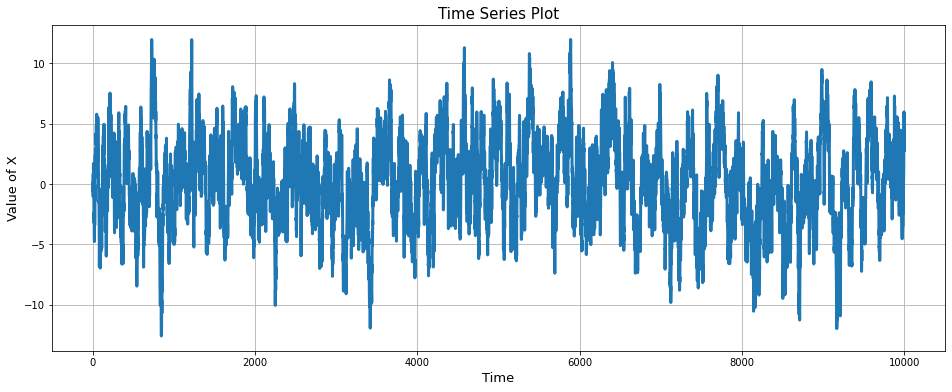

In [ ]:
def plot_series(X): 
    """ Plots the time series data X.
    
    Args:
        X (np.array): Time-series data
    """

    fig = plt.figure(figsize=(16, 6))
    plt.plot(X, linewidth=3)
    plt.title('Time Series Plot', fontsize=15)
    plt.xlabel('Time', fontsize=13)
    plt.ylabel('Value of X', fontsize=13)
    plt.grid()
    plt.show()

plot_series(X)

### ACF and PACF Plots

ACF stands for AutoCorrelation Function and PACF stands for Partial Autocorrelation Function. These functions give sample autocorrelation and sample partial autocorrelation values for a given time series. We can visualize the autocorrelations at different lags using the ACF plot and the PACF plot helps to visualize the nature of partial autocorrelations at different lags. 

We mentioned that using the process, we can generate any number of time series with any number of samples. The time series generated depends on the initialization involved. However, with a subsequently large number of samples, the ACF and PACF graphs tend to be the same.

Let's define a function `plot_graphs` which plots the ACF and PACF graph for AR model.  


In [ ]:
def plot_graphs(ar_params=None, X=None, figsize=(10, 5), get_X=False):
    """ Plot ACF and PACF graphs
    
        Takes in time series data and plots the ACF and PACF graphs for the 
        series. When the time series is not provided, it generates the time 
        series using ar params and plots the graphs.

    Args:
        X (np.array): Time series data
        ar_params (np.array): AR parameters - (phi1, phi2, ...)
        figsize (tuple): Size for the figure
        get_X (bool): If True returns the generated function X 
    
    """
    
    if X is None:
        ar = np.r_[1, -ar_params] 
        ar_process = ArmaProcess(ar, ma=[1]) 
        X = ar_process.generate_sample(nsample=10000) 

    fig = plt.figure(figsize=figsize)
    fig.subplots_adjust(hspace=0.45)
    
    title = 'Autocorrelation for AR model ~ {}'.format(str(ar_params))
    
    ax = fig.add_subplot(211)
    sm.graphics.tsa.plot_acf(X, ax=ax)
    ax.set_title(title, fontsize=14)
    
    title = 'Partial ' + title
    ax = fig.add_subplot(212)
    sm.graphics.tsa.plot_pacf(X, ax=ax)
    ax.set_title(title, fontsize=14)
    plt.show()

    if get_X:
        return X

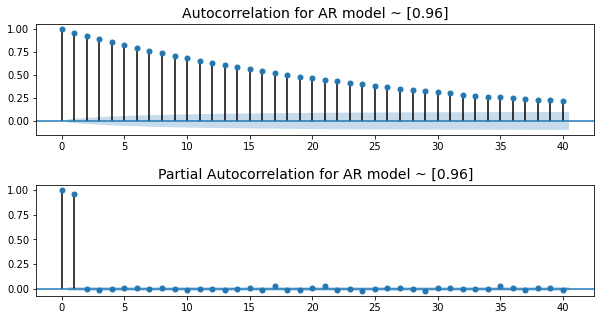

In [ ]:
plot_graphs(ar_params, X)

From the above ACF and PACF plots for the AR(1) process, we can see that the PACF values drop abruptly to about zero after lag 1, whereas the ACF values tail off or drop gradually. **Does the PACF plot for the AR model have any link with the order of the model?** Let's explore this further.


## Relation between Order and PACF Plot for AR Model

Let's begin with two AR models of orders 2 and 3 given below. We'll generate synthetic data using these models and then observe the nature of ACF and PACF plots. 

$\quad \quad
{
X_t = 0.5 X_{t-1} + 0.45 X_{t-2} + Z_t
\\
X_t = 0.4 X_{t-1} + 0.3 X_{t-2} + 0.26 X_{t-3} + Z_t
}
$

Also, we'll use the AR(3) model for showing model fitting. Let's get the generated data and assign it to the variable `X_3`.


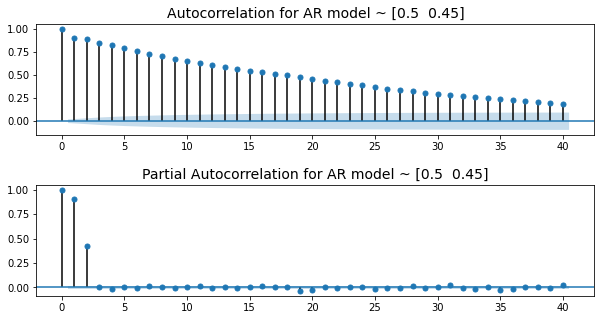

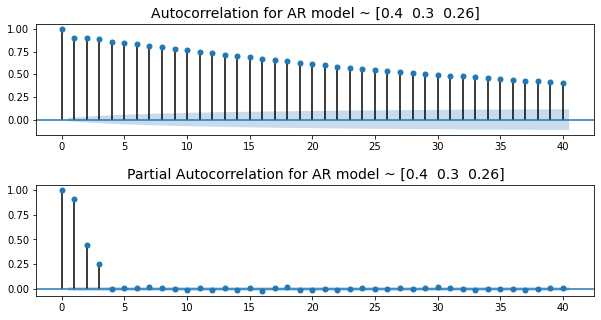

In [ ]:
ar_params1 = np.array([0.5, 0.45]) 
ar_params2 = np.array([0.4, 0.3, 0.26]) 

plot_graphs(ar_params1)
X_3 = plot_graphs(ar_params2, get_X=True)

### Observation

PACF values cut off after 2 and 3 lags for AR(2) and AR(3) models respectively. It looks like the **PACF values for AR(p) model drop abruptly after the first p lags**. It's the case actually, and we can prove it. However, the proof is out of the scope of this reading material.

Well, **how can we leverage this information**, we just obtained?

The thing is that when we get some real-world time series data on which we need to fit models, we don't know the underlying data generation process. To leverage the information we got here, we can plot the ACF and PACF for the time series data. And if the PACF follows the nature **`(ACF values tail off but PACF values cut off after some lags p)`** we saw earlier, we can fit an AR model of order p.





## Fitting AR(p) Model

Let's use the data `X_3` we generated for AR(3): $X_t = 0.4 X_{t-1} + 0.3 X_{t-2} + 0.26 X_{t-3} + Z_t$ model before. We know that the underlying data generation process is an AR process of order 3. However, for **real-world datasets**, we don't know the data generation process in advance. Hence, we need to plot the ACF and PACF graphs for the dataset, and as said earlier, if the plots follow the nature we discussed earlier, we can fit an AR model of the predicted order.

We will avoid the pre-step for this synthetic dataset `X_3` since we have already watched the plots for the datasets generated from different AR processes already. As we know, the order is three; we'll show how an AR(3) model can be fit. 

Note that an AR model is characterized by its parameters. We create an instance of [ARMA model](https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima_model.ARMA.html) specifying the data and the order of the model that can be fitted on the data, Then we fit the model using the `fit` method. This will result in finding the values for the parameters.


In [ ]:
ar_order = 3 # 3 order for ar_part
ma_order = 0 # 0 order for ma_part
order = (ar_order, ma_order)

# instantiate an AR model instance with the data and order and use fit method
ar_model = ARMA(X_3, order=order).fit(trend='nc')
ar_model.params

array([0.39924019, 0.30942456, 0.25168395])

The `ar_params` for the data generation process, $X_t = 0.4 X_{t-1} + 0.3 X_{t-2} + 0.26 X_{t-3} + Z_t$ , are $(0.4, 0.3, 0.26)$. The parameters of the fitted model, printed above, are near to these values. We've fitted the model, but what's under the hood? **How can an AR(p) model be fitted or how can we obtain the parameters of a model on a particular dataset?** One of the answers to this question is **Yule-Walker equations**, and we will now discuss about this.


### Yule-Walker Equations

The Yule–Walker equations are named after Udny Yule and Gilbert Walker. The following equations are called Yule-Walker Equations:
$$
\gamma_1 = \phi_1 \gamma_0 + \phi_2 \gamma_1 + \phi_3 \gamma_2 + ... + \phi_p \gamma_{p-1}
\\
\gamma_2 = \phi_1 \gamma_1 + \phi_2 \gamma_0 + \phi_3 \gamma_1 + ... + \phi_p \gamma_{p-2}
\\
\vdots
\\
\gamma_p = \phi_1 \gamma_{p - 1} + \phi_2 \gamma_{p - 2} + \phi_3 \gamma_{p - 3} + ... + \phi_p \gamma_0
$$

They relate autocovariance at different lags linearly with the AR parameters. Let's how these come around. 

\\


We take a stationary data $X$ such that $\newcommand{\E}[1]{\mathbb{E} [#1]} \E{X_t} = 0$ and $\E{X_t X_{t-h}}  = \gamma_h$ generated by the AR(p) process. It is given  by:

$$X_t = \phi_1 X_{t-1} + \phi_2 X_{t-2} + \phi_3 X_{t-3} + ... + \phi_p X_{t-p} + Z_t$$

\\

Multiplying by $X_{t-1}$ on both sides and taking expectation, we obtain the following equations.

$$X_t X_{t-1} = \phi_1 X_{t-1} X_{t-1} + \phi_2 X_{t-2} X_{t-1} + \phi_3 X_{t-3} X_{t-1} + ... + \phi_p X_{t-p} X_{t-1} + Z_t X_{t-1} $$

$$\E {X_t X_{t-1}} = \phi_1 \E {X_{t-1} X_{t-1}} + \phi_2 \E{X_{t-2} X_{t-1}} + \phi_3 \E{X_{t-3} X_{t-1}} + ... + \phi_p \E{X_{t-p} X_{t-1}} + \E{Z_t X_{t-1}} $$

\\

Then, using 

$\begin{align*}
\E{Z_t X_{t-h}} 
&= \E{Z_t} \E{X_{t-h}} [\because Z_t \text{ and } X_{t-h} \text{  are independent} ]\\
&= 0 \times \mu \\
&= 0
\end{align*}
$ \\
and \\
$\E {X_t X_{t-h}} = \gamma_h$, we get;

$$\gamma_1 = \phi_1 \gamma_0 + \phi_2 \gamma_1 + \phi_3 \gamma_2 + ... + \phi_p \gamma_{p-1}$$


Similarly, multiplying by $X_{t-2}, ..., X_{t-p}$, and following the same process, we can obtain the following equations.
$$
\gamma_2 = \phi_1 \gamma_1 + \phi_2 \gamma_0 + \phi_3 \gamma_1 + ... + \phi_p \gamma_{p-2}
\\
\vdots
\\
\gamma_p = \phi_1 \gamma_{p - 1} + \phi_2 \gamma_{p - 2} + \phi_3 \gamma_{p - 3} + ... + \phi_p \gamma_0$$

\\

These are the Yule-Walker Equations that we listed earlier. Let's formulate them in matrix form by converting autocovariance into autocorrelation. Since $\rho_h = \frac {\gamma_h}{\gamma_0}$, dividing by $\gamma_0$ on both sides, we get;

$$
\rho_1 = \phi_1 \rho_0 + \phi_2 \rho_1 + \phi_3 \rho_2 + ... + \phi_p \rho_{p-1}
\\
\rho_2 = \phi_1 \rho_1 + \phi_2 \rho_0 + \phi_3 \rho_1 + ... + \phi_p \rho_{p-2}
\\
\vdots
\\
\rho_p = \phi_1 \rho_{p - 1} + \phi_2 \rho_{p - 2} + \phi_3 \rho_{p - 3} + ... + \phi_p \rho_0$$

\\

Putting these above $p$ equations together in matrix form, we get.


$$
\begin{bmatrix}
\rho_1 \\
\rho_2 \\
\rho_3 \\
\vdots  \\
\rho_p
\end{bmatrix}
 = 
\begin{bmatrix}
\rho_0 & \rho_1 & \rho_2 & \cdots & \rho_{p-1} \\
\rho_1 & \rho_0 & \rho_1 & \cdots & \rho_{p-2} \\
\rho_2 & \rho_1 & \rho_0 & \cdots & \rho_{p-3} \\
\vdots  & \vdots  & \vdots & \ddots & \vdots  \\
\rho_{p-1} & \rho_{p-2} & \rho_{p-3} & \cdots & \rho_0 \\
\end{bmatrix}
\begin{bmatrix}
\phi_1 \\
\phi_2 \\
\phi_3 \\
\vdots \\
\phi_p
\end{bmatrix}
$$

We can write the above matrix equation in the form
$\mathbf{c} = \mathbf{C} \mathbf{\Phi}$. We can obtain sample autcorrelations of any given data using `statsmodels` function. Thus, we can obtain C and c. Hence, we can get the model parameters using $\mathbf{\Phi} = \mathbf{C} ^{-1} \mathbf{c}$. 


## Key Takeaways

1. In AR(p) model, $X_t$ is taken as the linear combination of the $p$ past values for $X$ $(X_{t-1}, X_{t-2}, X_{t-3}, . . . ,X_{t-p})$, plus some random noise $(Z_t)$.

2. The AR model handles only stationary data.
 
3. For the AR(p) model, PACF values cut off after lag p, whereas the ACF values tail off.

4. Yule-Walker equations can be used to get the solution for AR(p) model parameters.



## References

- Shumway R., Stoffer D. (2016) Time Series Analysis and Its Applications: With R Examples, 4th edition, Springer
    * Check definition 3.1 in page 78 for more information on autoregressive model.
